<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/01_data_and_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, time, math, random
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# seed information
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # deterministic can slow training, but makes runs reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


Mini Dataset Card (UCI HAR Inertial Signals)

Motivation / Intended use: Prototype on-device activity recognition from smartphone accelerometer + gyroscope windows, with emphasis on subject generalization and inference latency.

Target definition: 6-class activity label per window (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING).

Data source & license: UCI Human Activity Recognition (HAR) Dataset (windowed IMU signals). Use is for research/education; Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., & Parra, X. (2013). Human Activity Recognition Using Smartphones [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C54S4K.

Signals: Windowed time series at 50 Hz, window length 2.56 s = 128 timesteps. Channels: 9 inertial signals (3 body accel, 3 gyro, 3 total accel).

Known constraints: Must use sequential windows (RNN meaningful). Must use subject-disjoint split (no subject overlap between train/val and test).

Limitations / risks: Limited population and recording protocol; potential domain shift across devices/placement; labels may not cover real-world activity variation; misclassifications can impact user experience/safety in downstream applications.

Path Checking --> Ensure this is valid

In [ ]:
BASE = r"/content/UCI_Dataset"

assert os.path.isdir(BASE), f"BASE path not found: {BASE}"

print("BASE:", BASE)
print("Train dir exists:", os.path.isdir(os.path.join(BASE, "train")))
print("Test dir exists:", os.path.isdir(os.path.join(BASE, "test")))


BASE: /content/UCI_Dataset
Train dir exists: True
Test dir exists: True


Next we load the inertial signals (9 different txt files in each test/train folder). Stack all into one array (N, 128, 9)

In [ ]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

LABEL_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

def load_split(split: str):
    assert split in ["train", "test"]
    inertial_dir = os.path.join(BASE, split, "Inertial Signals")

    X_list = []
    for sig in SIGNALS:
        fp = os.path.join(inertial_dir, f"{sig}_{split}.txt")
        if not os.path.isfile(fp):
            raise FileNotFoundError(f"Missing file: {fp}")
        arr = np.loadtxt(fp)            # (N, 128)
        X_list.append(arr[..., None])   # (N, 128, 1)

    X = np.concatenate(X_list, axis=2)  # (N, 128, 9)

    y = np.loadtxt(os.path.join(BASE, split, f"y_{split}.txt")).astype(int) - 1  # 0..5
    subj = np.loadtxt(os.path.join(BASE, split, f"subject_{split}.txt")).astype(int)

    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

X_train_all, y_train_all, subj_train_all = load_split("train")
X_test,      y_test,      subj_test      = load_split("test")

print("Train:", X_train_all.shape, y_train_all.shape, subj_train_all.shape)
print("Test :", X_test.shape, y_test.shape, subj_test.shape)


Train: (7352, 128, 9) (7352,) (7352,)
Test : (2947, 128, 9) (2947,) (2947,)


Confirmation that the data is loaded correctly by checking:
- (N,T,C) shape of array
- Print label distribution
- Catch NaN values

In [ ]:
# 1) Confirm shapes (N, T, C)
Ntr, T, C = X_train_all.shape
Nte = X_test.shape[0]
print(f"Train shape: (N,T,C)=({Ntr},{T},{C})")
print(f"Test  shape: (N,T,C)=({Nte},{T},{C})")

# 2) Label distribution
print("Train label distribution:")
print(pd.Series(y_train_all).value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))

# 3) NaN/inf checks
print("\nFinite train:", np.isfinite(X_train_all).all())
print("Finite test :", np.isfinite(X_test).all())

assert np.isfinite(X_train_all).all(), "Found NaN/inf in training data"
assert np.isfinite(X_test).all(), "Found NaN/inf in test data"


Train shape: (N,T,C)=(7352,128,9)
Test  shape: (N,T,C)=(2947,128,9)
Train label distribution:
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
SITTING               1286
STANDING              1374
LAYING                1407
Name: count, dtype: int64

Test label distribution:
WALKING               496
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
SITTING               491
STANDING              532
LAYING                537
Name: count, dtype: int64

Finite train: True
Finite test : True


Leakage Check, ensures that there is no overlap in subjects between the train and test subjects.

In [ ]:
train_subjects = set(subj_train_all.tolist())
test_subjects  = set(subj_test.tolist())

overlap = train_subjects.intersection(test_subjects)
print("Subject overlap size:", len(overlap))
print("Overlap set:", overlap)

assert len(overlap) == 0, "Leakage detected: train/test share subjects!"


Subject overlap size: 0
Overlap set: set()


Conduct the disjoint split with the following information
- train-subjects
- validation-subjects
- train-subjects don't overlap with validation-subjects (leakage)
- neither overlaps test subjects

In [ ]:
def subject_disjoint_train_val_split(X, y, subj, val_frac=0.2, seed=42):
    set_global_seed(seed)
    uniq = np.array(sorted(set(subj.tolist())))
    rng = np.random.default_rng(seed)
    rng.shuffle(uniq)

    n_val = max(1, int(len(uniq) * val_frac))
    val_subjects = set(uniq[:n_val].tolist())
    tr_subjects  = set(uniq[n_val:].tolist())

    tr_mask  = np.isin(subj, list(tr_subjects))
    val_mask = np.isin(subj, list(val_subjects))

    X_tr, y_tr, subj_tr = X[tr_mask], y[tr_mask], subj[tr_mask]
    X_val, y_val, subj_val = X[val_mask], y[val_mask], subj[val_mask]

    # Safety checks
    assert len(set(subj_tr.tolist()).intersection(set(subj_val.tolist()))) == 0
    assert len(set(subj_tr.tolist()).intersection(set(subj_test.tolist()))) == 0
    assert len(set(subj_val.tolist()).intersection(set(subj_test.tolist()))) == 0

    return (X_tr, y_tr, subj_tr), (X_val, y_val, subj_val), (tr_subjects, val_subjects)

SEED = 42
(X_tr, y_tr, subj_tr), (X_val, y_val, subj_val), (tr_subj_set, val_subj_set) = subject_disjoint_train_val_split(
    X_train_all, y_train_all, subj_train_all, val_frac=0.2, seed=SEED
)

print("Train windows:", X_tr.shape, "Val windows:", X_val.shape)
print("Train subjects:", len(tr_subj_set), "Val subjects:", len(val_subj_set))
print("Train/Val subject overlap:", len(tr_subj_set.intersection(val_subj_set)))


Train windows: (5800, 128, 9) Val windows: (1552, 128, 9)
Train subjects: 17 Val subjects: 4
Train/Val subject overlap: 0


Baseline 0: trivial majority-class predictor

In [ ]:
majority = np.bincount(y_tr).argmax()
yhat_val = np.full_like(y_val, majority)

acc = accuracy_score(y_val, yhat_val)
mf1 = f1_score(y_val, yhat_val, average="macro")

print("Baseline0 majority class:", majority, LABEL_NAMES[majority])
print("Val accuracy:", acc)
print("Val macro-F1:", mf1)


Baseline0 majority class: 5 LAYING
Val accuracy: 0.18685567010309279
Val macro-F1: 0.05247918928700687


Build the Pytorch dataset + dataloaders
- Flatten for MLP

In [ ]:
class HARWindowDataset(Dataset):
    def __init__(self, X, y, flatten=False):
        self.X = torch.from_numpy(X)  # (N, T, C)
        self.y = torch.from_numpy(y)
        self.flatten = flatten

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (T, C)
        if self.flatten:
            x = x.reshape(-1)  # (T*C,)
        return x, self.y[idx]

def make_loaders(Xtr, ytr, Xva, yva, batch_size=128, flatten=False, num_workers=0):
    tr_ds = HARWindowDataset(Xtr, ytr, flatten=flatten)
    va_ds = HARWindowDataset(Xva, yva, flatten=flatten)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, drop_last=False)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
    return tr_dl, va_dl

BATCH_SIZE = 128
tr_dl_mlp, va_dl_mlp = make_loaders(X_tr, y_tr, X_val, y_val, batch_size=BATCH_SIZE, flatten=True)

Definitions of MLP Model
- MLP: Treat each window as a flat vector (ignore time order)

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self, in_dim=128*9, num_classes=6, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x):
        return self.net(x)


Training Utility class and functions

In [ ]:
@dataclass
class RunConfig:
    run_name: str
    seed: int
    lr: float
    weight_decay: float
    max_epochs: int
    patience: int
    grad_clip: float
    hidden: int = 256
    dropout: float = 0.2

def evaluate(model, dl):
    model.eval()
    ys, yh = [], []
    with torch.no_grad():
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            pred = logits.argmax(dim=1)
            ys.append(y.cpu().numpy())
            yh.append(pred.cpu().numpy())
    ys = np.concatenate(ys)
    yh = np.concatenate(yh)
    return {
        "acc": float(accuracy_score(ys, yh)),
        "macro_f1": float(f1_score(ys, yh, average="macro")),
        "y_true": ys,
        "y_pred": yh,
    }

def train_one_run(cfg: RunConfig, tr_dl, va_dl, model, out_dir="artifacts"):
    os.makedirs(out_dir, exist_ok=True)
    set_global_seed(cfg.seed)
    model = model.to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val = -1e9
    best_path = os.path.join(out_dir, f"{cfg.run_name}_best.pt")
    bad_epochs = 0

    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        for x, y in tr_dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite loss encountered (NaN/inf).")

            loss.backward()
            if cfg.grad_clip and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()

        va_eval = evaluate(model, va_dl)
        print(f"Epoch {epoch:3d} | val_acc={va_eval['acc']:.4f} | val_macro_f1={va_eval['macro_f1']:.4f}")

        if va_eval["macro_f1"] > best_val:
            best_val = va_eval["macro_f1"]
            bad_epochs = 0
            torch.save({"model_state": model.state_dict()}, best_path)
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.patience:
                break

    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    final_val = evaluate(model, va_dl)
    return best_path, final_val


Functions to add information to CSV output log, generate F1 table, create confusion matrix.

In [ ]:
LOG_PATH = "experiment_log.csv"

def append_log_row(row: dict, path=LOG_PATH):
    df = pd.DataFrame([row])
    if os.path.isfile(path):
        df.to_csv(path, mode="a", header=False, index=False)
    else:
        df.to_csv(path, index=False)

def per_class_f1_table(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
    rows = []
    for i, name in enumerate(LABEL_NAMES):
        rows.append({
            "class": name,
            "precision": report[name]["precision"],
            "recall": report[name]["recall"],
            "f1": report[name]["f1-score"],
            "support": report[name]["support"],
        })
    return pd.DataFrame(rows)

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.xticks(range(len(LABEL_NAMES)), LABEL_NAMES, rotation=45, ha="right")
    plt.yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Training for MLP baseline

In [ ]:
cfg_mlp = RunConfig(
    run_name="mlp_baseline_v1",
    seed=42,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=50,
    patience=8,
    grad_clip=1.0,
    hidden=256,
    dropout=0.2
)


mlp = MLPBaseline(in_dim=128*9, num_classes=6, hidden=cfg_mlp.hidden, dropout=cfg_mlp.dropout)

best_path, val_metrics = train_one_run(cfg_mlp, tr_dl_mlp, va_dl_mlp, mlp, out_dir="artifacts")

print("Best checkpoint:", best_path)
display(hist_df.tail(10))


Epoch   1 | val_acc=0.7539 | val_macro_f1=0.7232
Epoch   2 | val_acc=0.8595 | val_macro_f1=0.8399
Epoch   3 | val_acc=0.8653 | val_macro_f1=0.8546
Epoch   4 | val_acc=0.8653 | val_macro_f1=0.8601
Epoch   5 | val_acc=0.9143 | val_macro_f1=0.9112
Epoch   6 | val_acc=0.8930 | val_macro_f1=0.8908
Epoch   7 | val_acc=0.8860 | val_macro_f1=0.8854
Epoch   8 | val_acc=0.8963 | val_macro_f1=0.8950
Epoch   9 | val_acc=0.8988 | val_macro_f1=0.8975
Epoch  10 | val_acc=0.8872 | val_macro_f1=0.8847
Epoch  11 | val_acc=0.8853 | val_macro_f1=0.8836
Epoch  12 | val_acc=0.8885 | val_macro_f1=0.8878
Epoch  13 | val_acc=0.8827 | val_macro_f1=0.8797
Best checkpoint: artifacts/mlp_baseline_v1_best.pt


,epoch,train_loss,val_loss,val_acc,val_macro_f1,lr
4,5,0.160366,0.256923,0.907216,0.903348,0.001
5,6,0.128610,0.220095,0.915593,0.914607,0.001
6,7,0.122093,0.273106,0.888531,0.887456,0.001
7,8,0.131293,0.278670,0.893686,0.891233,0.001
8,9,0.113161,0.351997,0.893686,0.890624,0.001
9,10,0.110289,0.356880,0.872423,0.870859,0.001
10,11,0.114011,0.305695,0.897552,0.897544,0.001
11,12,0.114529,0.318074,0.885309,0.885064,0.001
12,13,0.105783,0.354435,0.902062,0.903267,0.001
13,14,0.101344,0.448110,0.871134,0.869533,0.001


Output cell for MLP training

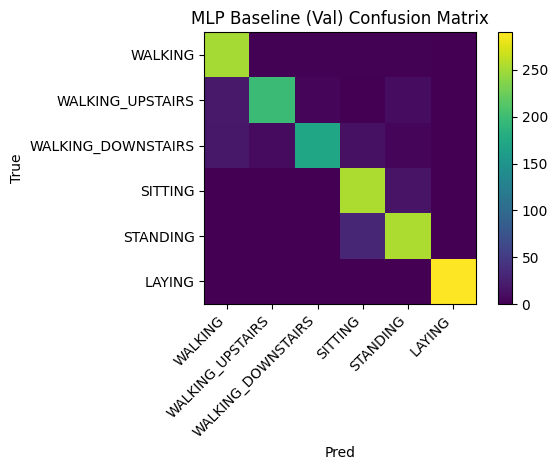

,class,precision,recall,f1,support
0,WALKING,0.865517,0.969112,0.914390,259.0
1,WALKING_UPSTAIRS,0.951923,0.849785,0.897959,233.0
2,WALKING_DOWNSTAIRS,0.960894,0.796296,0.870886,216.0
3,SITTING,0.846667,0.944238,0.892794,269.0
4,STANDING,0.891228,0.891228,0.891228,285.0
5,LAYING,1.000000,1.000000,1.000000,290.0


Val accuracy: 0.9143041237113402
Val macro-F1: 0.9112095842553991


In [ ]:
y_true = val_metrics["y_true"]
y_pred = val_metrics["y_pred"]

plot_confusion(y_true, y_pred, title="MLP Baseline (Val) Confusion Matrix")

tbl = per_class_f1_table(y_true, y_pred)
display(tbl)

print("Val accuracy:", accuracy_score(y_true, y_pred))
print("Val macro-F1:", f1_score(y_true, y_pred, average="macro"))


Append MLP run data to CSV

In [ ]:
row = {
    "run": cfg_mlp.run_name,
    "model": "MLP",
    "params": str(asdict(cfg_mlp)),
    "seed": cfg_mlp.seed,
    "val_acc": val_metrics["acc"],
    "val_macro_f1": val_metrics["macro_f1"],
    "timestamp": datetime.now().isoformat(),
    "best_ckpt": best_path,
    "eval_source": "val_subjects_only"
}
append_log_row(row)

print("Wrote log row to", LOG_PATH)
#print(pd.read_csv(LOG_PATH).tail(5))


Wrote log row to experiment_log.csv



## Results & Discussion
We enforced a subject-disjoint setup using the provided train/test split and verified subject overlap = 0. Validation was created from training subjects only to avoid test leakage. The MLP baseline trained on flattened windows (128×9) achieved strong validation performance and produced most errors between similar activities (walking variants and sitting vs standing), which is expected for short IMU windows.because these pairs can have similar IMU patterns over short windows. LAYING was easiest for both models and was near-perfect.
